In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kruskal, gaussian_kde
from scipy.optimize import curve_fit
from scikit_posthocs import posthoc_dunn

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import (train_test_split, StratifiedKFold, KFold, cross_val_score, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score)

def rmse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

def washburn_radius(L, gamma, t, phi, eta):
    L = np.asarray(L, dtype=float)
    gamma = np.asarray(gamma, dtype=float)
    t = np.asarray(t, dtype=float)
    phi = np.asarray(phi, dtype=float)
    eta = np.asarray(eta, dtype=float)
    denom = gamma * t * np.cos(phi)
    return (2 * eta * L**2) / denom

def washburn_length(r, gamma, t, phi, eta):
    r = np.asarray(r, dtype=float)
    gamma = np.asarray(gamma, dtype=float)
    t = np.asarray(t, dtype=float)
    phi = np.asarray(phi, dtype=float)
    eta = np.asarray(eta, dtype=float)
    inside = (gamma * r * t * np.cos(phi)) / (2 * eta)
    return np.sqrt(inside)

def evaluate_regression(y_true, y_pred):
    return {"MAE": mean_absolute_error(y_true, y_pred), "RMSE": rmse(y_true, y_pred), "R2": r2_score(y_true, y_pred)}

def inspect_dataframe(name, df):
    print(f"\n{'='*70}")
    print(name)
    print(f"{'='*70}")
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nHead:")
    print(df.head())
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nSummary statistics:")
    print(df.describe(include="all"))


dunking-data.csv
Shape: (3000, 6)

Columns: ['gamma', 'phi', 'eta', 'L', 't', 'biscuit']

Head:
      gamma       phi       eta         L          t    biscuit
0  0.073897  1.333006  0.000999  0.011196  19.362214  Digestive
1  0.080946  1.476758  0.001012  0.005894  11.852589  Digestive
2  0.087408  1.477141  0.000984  0.009249  24.793669  Digestive
3  0.070793  1.502001  0.001002  0.003774  16.292780     Hobnob
4  0.058917  1.548274  0.001004  0.002291  13.662271     Hobnob

Missing values:
gamma      0
phi        0
eta        0
L          0
t          0
biscuit    0
dtype: int64

Duplicate rows: 0

Summary statistics:
              gamma          phi          eta            L            t  \
count   3000.000000  3000.000000  3000.000000  3000.000000  3000.000000   
unique          NaN          NaN          NaN          NaN          NaN   
top             NaN          NaN          NaN          NaN          NaN   
freq            NaN          NaN          NaN          NaN          NaN

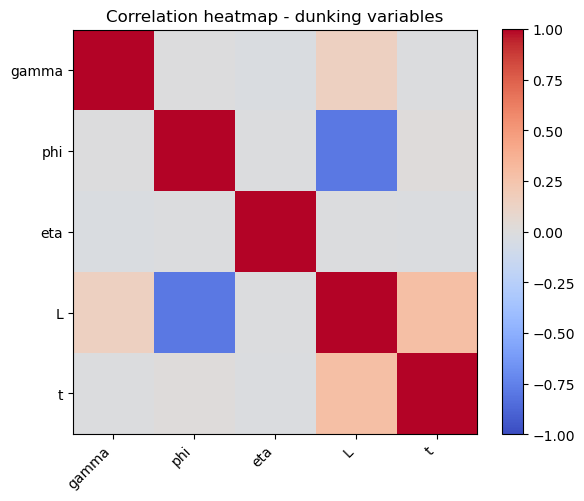

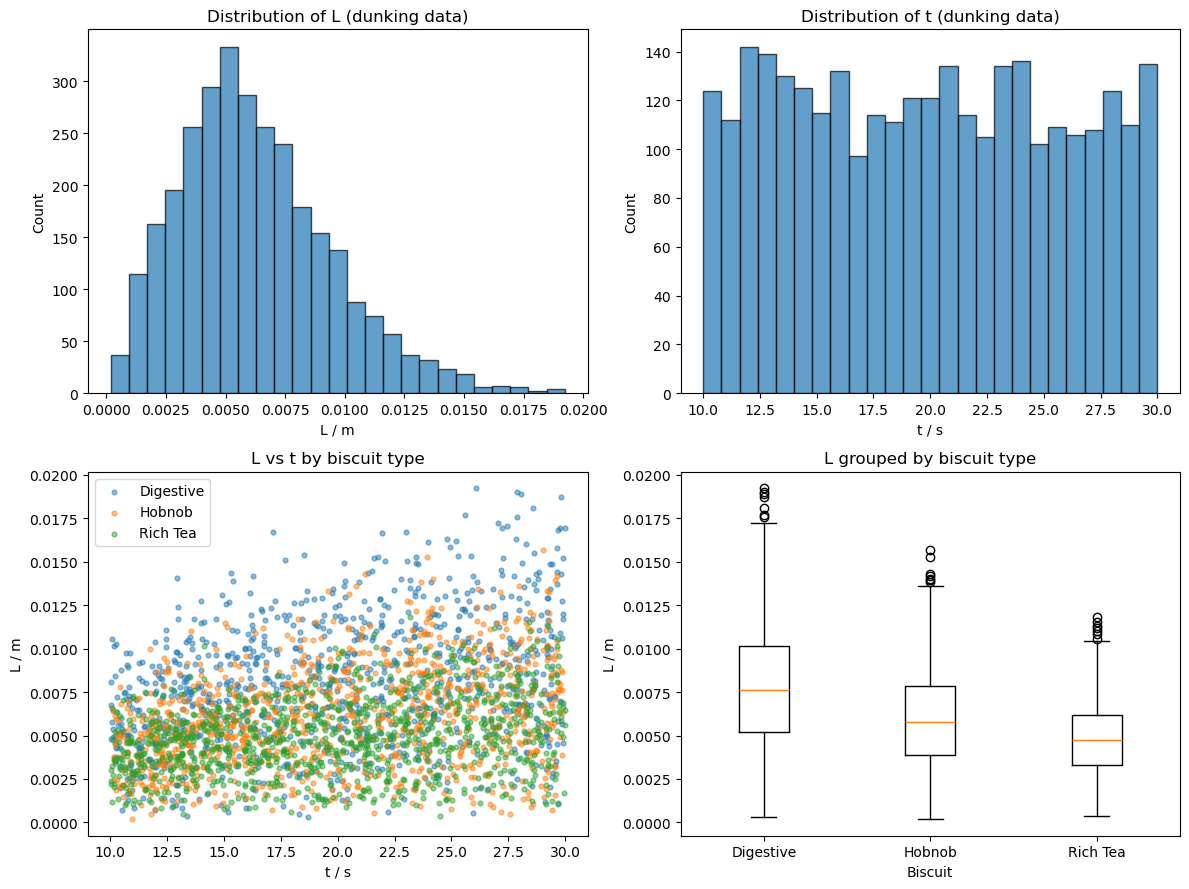

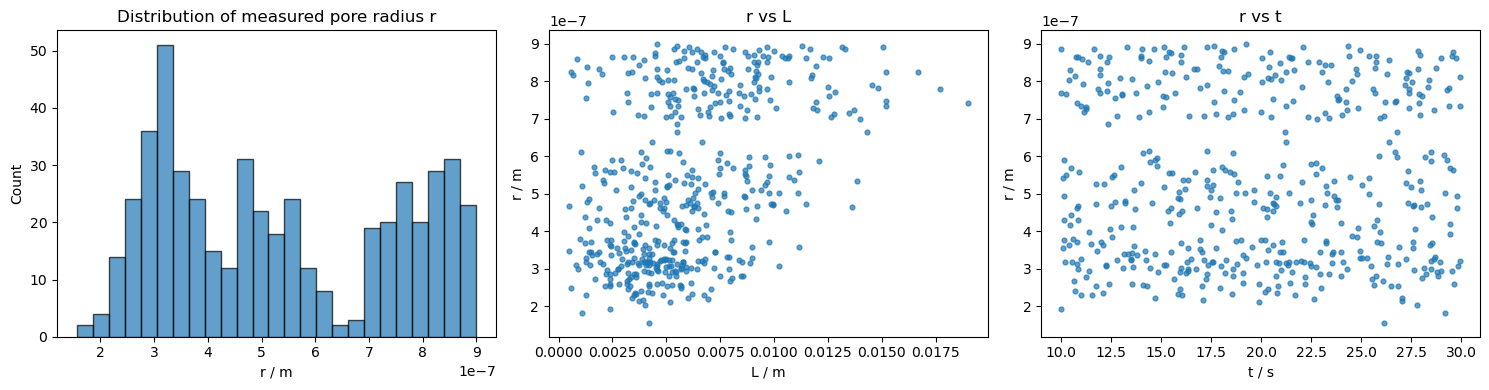

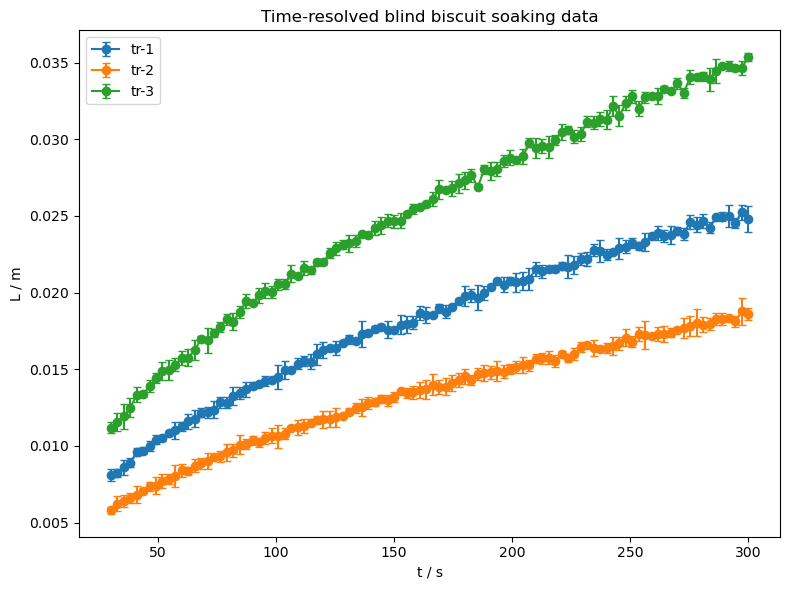

In [3]:
dunk = pd.read_csv("dunking-data.csv")
micro = pd.read_csv("microscopy-data.csv")
tr1 = pd.read_csv("tr-1.csv")
tr2 = pd.read_csv("tr-2.csv")
tr3 = pd.read_csv("tr-3.csv")

blind_samples = {"tr-1": tr1.copy(), "tr-2": tr2.copy(), "tr-3": tr3.copy()}

inspect_dataframe("dunking-data.csv", dunk)
inspect_dataframe("microscopy-data.csv", micro)
inspect_dataframe("tr-1.csv", tr1)
inspect_dataframe("tr-2.csv", tr2)
inspect_dataframe("tr-3.csv", tr3)

print("\nBiscuit class counts:")
print(dunk["biscuit"].value_counts())

dunk["abs_cos_phi"] = np.abs(np.cos(dunk["phi"]))
micro["abs_cos_phi"] = np.abs(np.cos(micro["phi"]))

print("\nPotentially inaccurate Washburn inversions")
print("dunk rows with |cos(phi)| < 0.001:", int((dunk["abs_cos_phi"] < 0.001).sum()))
print("micro rows with |cos(phi)| < 0.001:", int((micro["abs_cos_phi"] < 0.001).sum()))

corr_cols = ["gamma", "phi", "eta", "L", "t"] #correlation heatmap
corr = dunk[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
ax.set_title("Correlation heatmap - dunking variables")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 9)) #distribution and scatter plots 

axes[0, 0].hist(dunk["L"], bins=25, edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Distribution of L (dunking data)")
axes[0, 0].set_xlabel("L / m")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(dunk["t"], bins=25, edgecolor="black", alpha=0.7)
axes[0, 1].set_title("Distribution of t (dunking data)")
axes[0, 1].set_xlabel("t / s")
axes[0, 1].set_ylabel("Count")

for biscuit in dunk["biscuit"].unique():
    sub = dunk[dunk["biscuit"] == biscuit]
    axes[1, 0].scatter(sub["t"], sub["L"], alpha=0.5, s=12, label=biscuit)
axes[1, 0].set_title("L vs t by biscuit type")
axes[1, 0].set_xlabel("t / s")
axes[1, 0].set_ylabel("L / m")
axes[1, 0].legend()

biscuit_order = sorted(dunk["biscuit"].unique())
box_data = [dunk.loc[dunk["biscuit"] == b, "L"] for b in biscuit_order]
axes[1, 1].boxplot(box_data, tick_labels=biscuit_order)
axes[1, 1].set_title("L grouped by biscuit type")
axes[1, 1].set_xlabel("Biscuit")
axes[1, 1].set_ylabel("L / m")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4)) #micro scatter plots
axes[0].hist(micro["r"], bins=25, edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of measured pore radius r")
axes[0].set_xlabel("r / m")
axes[0].set_ylabel("Count")
axes[1].scatter(micro["L"], micro["r"], alpha=0.7, s=12)
axes[1].set_title("r vs L")
axes[1].set_xlabel("L / m")
axes[1].set_ylabel("r / m")
axes[2].scatter(micro["t"], micro["r"], alpha=0.7, s=12)
axes[2].set_title("r vs t")
axes[2].set_xlabel("t / s")
axes[2].set_ylabel("r / m")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6)) #blind time data
for name, df in blind_samples.items():
    ax.errorbar(df["t"], df["L"], yerr=df["dL"], fmt="o-", capsize=3, label=name)
ax.set_title("Time-resolved blind biscuit soaking data")
ax.set_xlabel("t / s")
ax.set_ylabel("L / m")
ax.legend()
plt.tight_layout()
plt.show()

Dunking data with inferred effective pore radius:
      gamma       phi       eta         L          t    biscuit         r_eff
0  0.073897  1.333006  0.000999  0.011196  19.362214  Digestive  7.429094e-07
1  0.080946  1.476758  0.001012  0.005894  11.852589  Digestive  7.803690e-07
2  0.087408  1.477141  0.000984  0.009249  24.793669  Digestive  8.302559e-07
3  0.070793  1.502001  0.001002  0.003774  16.292780     Hobnob  3.598074e-07
4  0.058917  1.548274  0.001004  0.002291  13.662271     Hobnob  5.814437e-07

r_eff outliers outside IQR bounds: 0

Summary of inferred effective pore radius by biscuit:
           count          mean        median           std           min  \
biscuit                                                                    
Digestive   1000  8.021261e-07  8.049362e-07  5.964216e-08  6.766981e-07   
Hobnob      1000  5.003074e-07  5.008655e-07  8.079370e-08  2.337422e-07   
Rich Tea    1000  3.020585e-07  3.038294e-07  5.068362e-08  1.328849e-07   

        

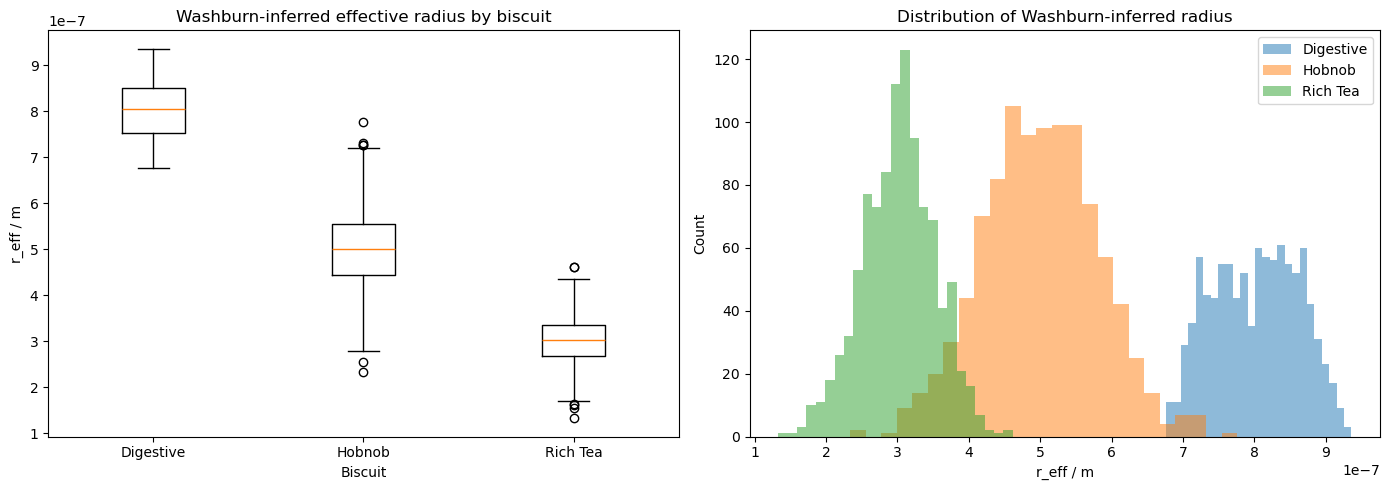


Microscopy comparison metrics
Radius comparison: {'MAE': 8.235688805480634e-09, 'RMSE': 1.094522652440573e-08, 'R2': 0.9974355340071894}
Length prediction using microscopy radius: {'MAE': 4.636394889666097e-05, 'RMSE': 6.434742175559671e-05, 'R2': 0.9995897989551944}


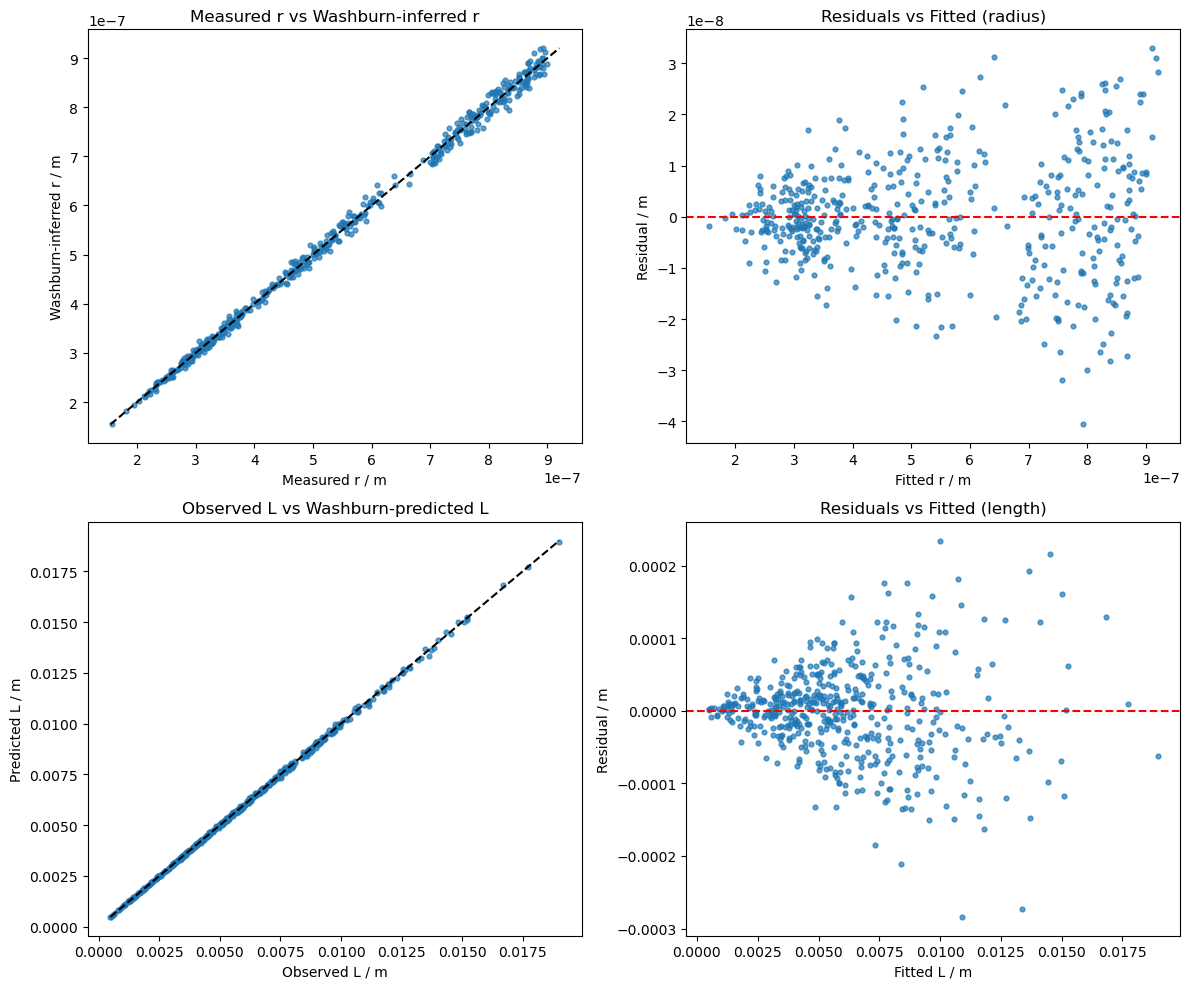

tr-1: r_fit = 5.1862e-07 +/- 1.0284e-09 m
tr-2: r_fit = 2.8026e-07 +/- 9.6853e-10 m
tr-3: r_fit = 1.0048e-06 +/- 4.5343e-10 m

Blind sample radius summary:
  sample    mean_r_eff  median_r_eff     std_r_eff         r_fit     r_fit_err
2   tr-3  1.003606e-06  1.002283e-06  1.938550e-08  1.004803e-06  4.534299e-10
0   tr-1  5.190558e-07  5.200957e-07  1.042269e-08  5.186196e-07  1.028353e-09
1   tr-2  2.794291e-07  2.794716e-07  5.364656e-09  2.802635e-07  9.685285e-10


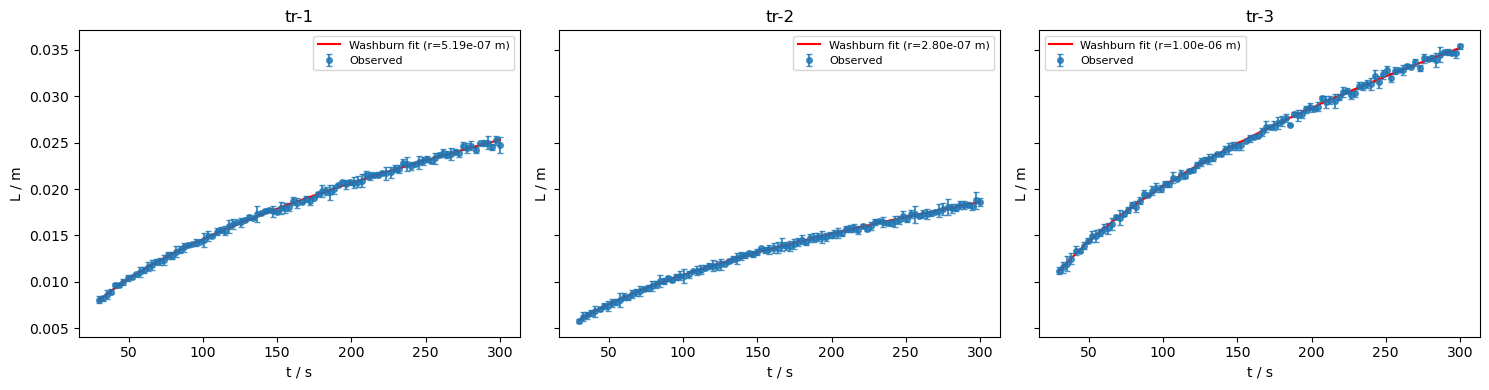

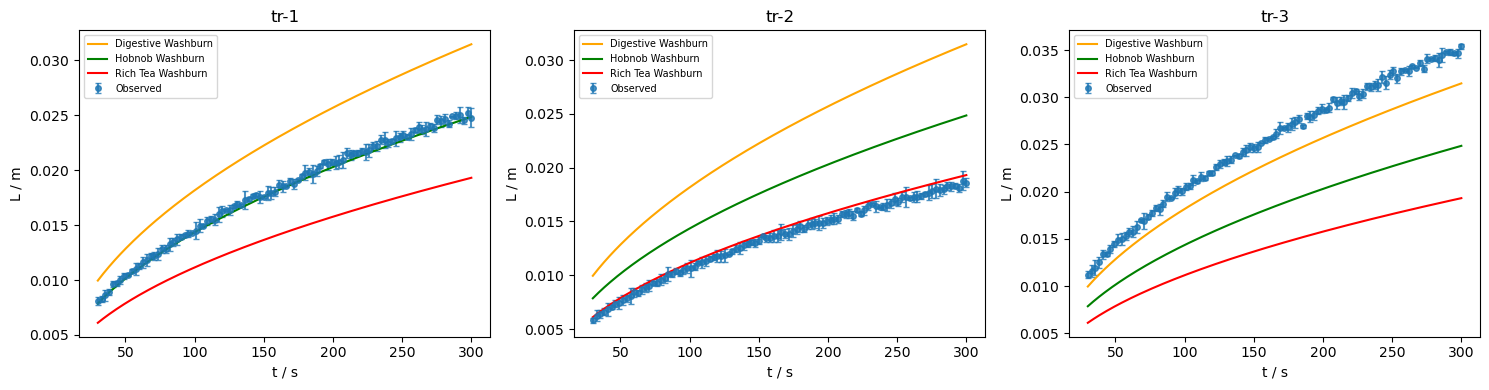

In [4]:
dunk_phys = dunk.copy()
micro_phys = micro.copy()

dunk_phys["r_eff"] = washburn_radius(L=dunk_phys["L"], gamma=dunk_phys["gamma"], t=dunk_phys["t"], phi=dunk_phys["phi"], eta=dunk_phys["eta"]) #effective pore radius from Washburn equation

print("Dunking data with inferred effective pore radius:")
print(dunk_phys[["gamma", "phi", "eta", "L", "t", "biscuit", "r_eff"]].head())

q1 = dunk_phys["r_eff"].quantile(0.25) #find outliers with interquartile range
q3 = dunk_phys["r_eff"].quantile(0.75)
iqr = q3 - q1
n_outliers = int(((dunk_phys["r_eff"] < q1 - 1.5*iqr) | (dunk_phys["r_eff"] > q3 + 1.5*iqr)).sum()) #count outliers
print(f"\nr_eff outliers outside IQR bounds: {n_outliers}")

radius_summary = (dunk_phys.groupby("biscuit")["r_eff"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("mean", ascending=False)) #summarise each biscuit type
print("\nSummary of inferred effective pore radius by biscuit:")
print(radius_summary)

biscuit_order = sorted(dunk_phys["biscuit"].unique()) #kruskal-wallis test
groups = [dunk_phys.loc[dunk_phys["biscuit"] == b, "r_eff"].dropna().values for b in biscuit_order] #seperate r_eff into one group / bisucit 
kw_stat, kw_p = kruskal(*groups) #tests if r_eff distributions differ significantly
print(f"\nKruskal-Wallis test: H = {kw_stat:.4f}, p = {kw_p:.4e}")

dunn_data = dunk_phys.dropna(subset=["r_eff"]) #post hoc dunns test
dunn_result = posthoc_dunn(dunn_data, val_col="r_eff", group_col="biscuit", p_adjust="bonferroni") #sees which biscuit pairs differ significantly
print("\nDunn's post-hoc test:")
print(dunn_result)

fig, axes = plt.subplots(1, 2, figsize=(14, 5)) #effective pore radius by biscuit type

box_data = [dunk_phys.loc[dunk_phys["biscuit"] == b, "r_eff"].dropna() for b in biscuit_order]
axes[0].boxplot(box_data, tick_labels=biscuit_order)
axes[0].set_title("Washburn-inferred effective radius by biscuit")
axes[0].set_xlabel("Biscuit")
axes[0].set_ylabel("r_eff / m")
axes[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

for biscuit in biscuit_order:
    sub = dunk_phys[dunk_phys["biscuit"] == biscuit]
    axes[1].hist(sub["r_eff"].dropna(), bins=25, alpha=0.5, label=biscuit)
axes[1].set_title("Distribution of Washburn-inferred radius")
axes[1].set_xlabel("r_eff / m")
axes[1].set_ylabel("Count")
axes[1].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
axes[1].legend()
plt.tight_layout()
plt.show()

micro_phys["r_washburn"] = washburn_radius(L=micro_phys["L"], gamma=micro_phys["gamma"], t=micro_phys["t"], phi=micro_phys["phi"], eta=micro_phys["eta"]) #compare micro r against measured pore r
micro_phys["L_washburn_from_r"] = washburn_length(r=micro_phys["r"], gamma=micro_phys["gamma"], t=micro_phys["t"], phi=micro_phys["phi"], eta=micro_phys["eta"]) #predict L from micro r
micro_phys["r_residual"] = micro_phys["r_washburn"] - micro_phys["r"]
micro_phys["L_residual"] = micro_phys["L_washburn_from_r"] - micro_phys["L"]

mask_r = micro_phys["r"].notna() & micro_phys["r_washburn"].notna()
mask_L = micro_phys["L"].notna() & micro_phys["L_washburn_from_r"].notna()

r_metrics = evaluate_regression(micro_phys.loc[mask_r, "r"], micro_phys.loc[mask_r, "r_washburn"])
L_metrics = evaluate_regression(micro_phys.loc[mask_L, "L"], micro_phys.loc[mask_L, "L_washburn_from_r"])

print("\nMicroscopy comparison metrics")
print("Radius comparison:", r_metrics)
print("Length prediction using microscopy radius:", L_metrics)

fig, axes = plt.subplots(2, 2, figsize=(12, 10)) #micro plots with residuals

r_min = np.nanmin([micro_phys["r"].min(), micro_phys["r_washburn"].min()])
r_max = np.nanmax([micro_phys["r"].max(), micro_phys["r_washburn"].max()])
axes[0, 0].scatter(micro_phys["r"], micro_phys["r_washburn"], alpha=0.7, s=12)
axes[0, 0].plot([r_min, r_max], [r_min, r_max], "k--")
axes[0, 0].set_title("Measured r vs Washburn-inferred r")
axes[0, 0].set_xlabel("Measured r / m")
axes[0, 0].set_ylabel("Washburn-inferred r / m")
axes[0, 0].ticklabel_format(axis="both", style="sci", scilimits=(0, 0))

axes[0, 1].scatter(micro_phys["r_washburn"], micro_phys["r_residual"], alpha=0.7, s=12)
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].set_title("Residuals vs Fitted (radius)")
axes[0, 1].set_xlabel("Fitted r / m")
axes[0, 1].set_ylabel("Residual / m")
axes[0, 1].ticklabel_format(axis="both", style="sci", scilimits=(0, 0))

L_min = np.nanmin([micro_phys["L"].min(), micro_phys["L_washburn_from_r"].min()])
L_max = np.nanmax([micro_phys["L"].max(), micro_phys["L_washburn_from_r"].max()])
axes[1, 0].scatter(micro_phys["L"], micro_phys["L_washburn_from_r"], alpha=0.7, s=12)
axes[1, 0].plot([L_min, L_max], [L_min, L_max], "k--")
axes[1, 0].set_title("Observed L vs Washburn-predicted L")
axes[1, 0].set_xlabel("Observed L / m")
axes[1, 0].set_ylabel("Predicted L / m")

axes[1, 1].scatter(micro_phys["L_washburn_from_r"], micro_phys["L_residual"], alpha=0.7, s=12)
axes[1, 1].axhline(0, color="red", linestyle="--")
axes[1, 1].set_title("Residuals vs Fitted (length)")
axes[1, 1].set_xlabel("Fitted L / m")
axes[1, 1].set_ylabel("Residual / m")

plt.tight_layout()
plt.show()

gamma_tr = 6.78e-2 #effective radius and washburn fit
phi_tr = 1.45
eta_tr = 9.93e-4

def washburn_curve(t, r):
    return np.sqrt((gamma_tr * r * t * np.cos(phi_tr)) / (2 * eta_tr))

blind_phys = {}
blind_fit_results = {}

for name, df in blind_samples.items():
    df = df.copy()
    df["gamma"] = gamma_tr
    df["phi"] = phi_tr
    df["eta"] = eta_tr

    df["r_eff"] = washburn_radius(L=df["L"].values, gamma=df["gamma"].values, t=df["t"].values, phi=df["phi"].values, eta=df["eta"].values) 
    with np.errstate(divide="ignore", invalid="ignore"):
        df["dr_eff"] = np.abs((4 * eta_tr * df["L"].values) / (gamma_tr * df["t"].values * np.cos(phi_tr))) * df["dL"].values

    blind_phys[name] = df

    popt, pcov = curve_fit(washburn_curve, df["t"].values, df["L"].values, p0=[1e-6], sigma=df["dL"].values, absolute_sigma=True) #fit washburn curve to blind data
    r_fit = popt[0]
    r_fit_err = np.sqrt(pcov[0, 0])
    blind_fit_results[name] = {"r_fit": r_fit, "r_fit_err": r_fit_err}
    print(f"{name}: r_fit = {r_fit:.4e} +/- {r_fit_err:.4e} m")

blind_radius_summary = []

for name, df in blind_phys.items():
    blind_radius_summary.append({"sample": name, "mean_r_eff": df["r_eff"].mean(), "median_r_eff": df["r_eff"].median(), "std_r_eff": df["r_eff"].std(), "r_fit": blind_fit_results[name]["r_fit"], "r_fit_err": blind_fit_results[name]["r_fit_err"],})

blind_radius_summary = pd.DataFrame(blind_radius_summary).sort_values("r_fit", ascending=False)
print("\nBlind sample radius summary:")
print(blind_radius_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, df) in zip(axes, blind_phys.items()):
    ax.errorbar(df["t"], df["L"], yerr=df["dL"], fmt="o", capsize=2, ms=4, alpha=0.8, label="Observed")
    t_smooth = np.linspace(df["t"].min(), df["t"].max(), 200)
    r_fit = blind_fit_results[name]["r_fit"]
    ax.plot(t_smooth, washburn_curve(t_smooth, r_fit), "r-",
            label=f"Washburn fit (r={r_fit:.2e} m)")
    ax.set_title(name)
    ax.set_xlabel("t / s")
    ax.set_ylabel("L / m")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

mean_r_by_biscuit = dunk_phys.groupby("biscuit")["r_eff"].mean() #plot blind data with all three class Washburn curves

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colours = {"Digestive": "orange", "Hobnob": "green", "Rich Tea": "red"}
for ax, (name, df) in zip(axes, blind_phys.items()):
    ax.errorbar(df["t"], df["L"], yerr=df["dL"], fmt="o", capsize=2, ms=4, alpha=0.8, label="Observed")
    t_smooth = np.linspace(df["t"].min(), df["t"].max(), 200)
    for biscuit, colour in colours.items():
        r_mean = mean_r_by_biscuit[biscuit]
        ax.plot(t_smooth, washburn_curve(t_smooth, r_mean), color=colour, label=f"{biscuit} Washburn")
    ax.set_title(name)
    ax.set_xlabel("t / s")
    ax.set_ylabel("L / m")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


Classification results (measured variables only):
                 model  test_accuracy  precision_macro  recall_macro  \
2                  SVM       0.893333         0.893046      0.893333   
1        Random Forest       0.816667         0.815133      0.816667   
0  Logistic Regression       0.751667         0.746100      0.751667   

   f1_macro  cv_accuracy_mean  cv_accuracy_std  
2  0.893178          0.889667         0.009274  
1  0.815599          0.808667         0.010296  
0  0.745285          0.738667         0.007557  

Logistic Regression
              precision    recall  f1-score   support

   Digestive       0.78      0.86      0.82       200
      Hobnob       0.69      0.56      0.61       200
    Rich Tea       0.77      0.83      0.80       200

    accuracy                           0.75       600
   macro avg       0.75      0.75      0.75       600
weighted avg       0.75      0.75      0.75       600


Random Forest
              precision    recall  f1-score   s

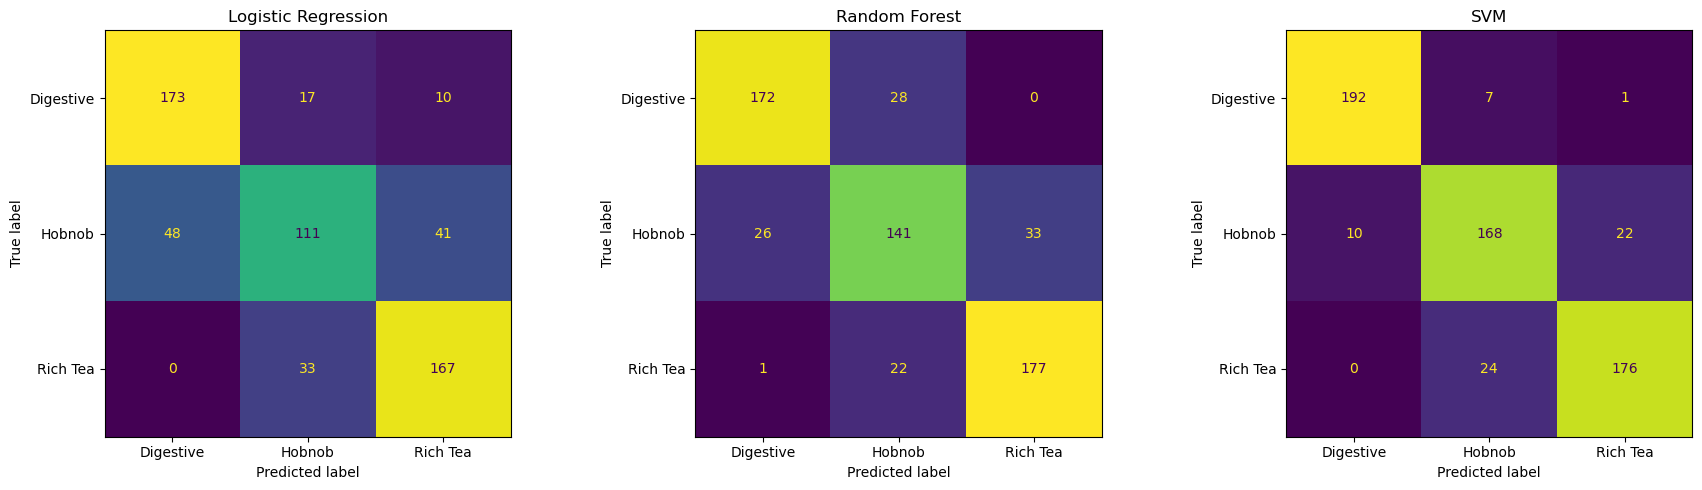


MLP final test accuracy: 0.9300


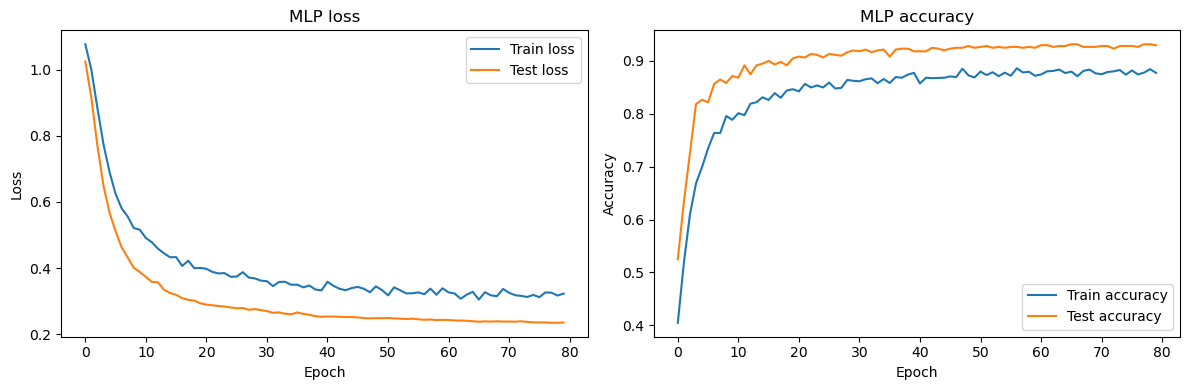


MLP classification report:
              precision    recall  f1-score   support

   Digestive       0.97      0.95      0.96       200
      Hobnob       0.93      0.87      0.90       200
    Rich Tea       0.89      0.97      0.93       200

    accuracy                           0.93       600
   macro avg       0.93      0.93      0.93       600
weighted avg       0.93      0.93      0.93       600



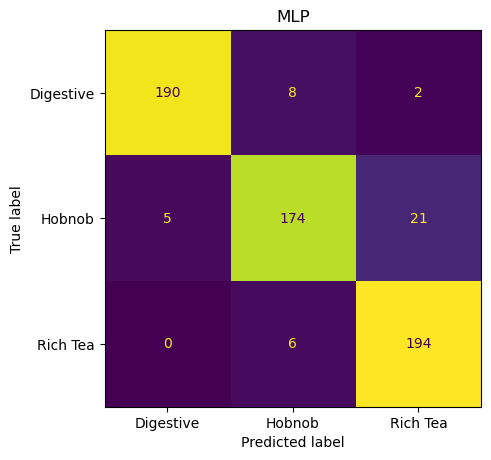

In [5]:
features_measured = ["gamma", "phi", "eta", "L", "t"] #measured variables only
X_measured = dunk[features_measured].copy()
y = dunk["biscuit"].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_measured, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

measured_models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, random_state=42))]),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": GridSearchCV(Pipeline([("scaler", StandardScaler()), ("model", SVC(random_state=42))]), param_grid={"model__C": [0.1, 1, 10, 100], "model__gamma": ["scale", "auto"]}, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring="accuracy", n_jobs=-1) #tune SVM hyperparameters via cross-validation
}

measured_results = []
fitted_measured_models = {}
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in measured_models.items():
    model.fit(X_train, y_train)
    fitted_measured_models[name] = model

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)

    cv_scores = cross_val_score(model, X_measured, y_encoded, cv=cv_splitter, scoring="accuracy")

    measured_results.append({"model": name, "test_accuracy": acc, "precision_macro": prec, "recall_macro": rec, "f1_macro": f1, "cv_accuracy_mean": cv_scores.mean(), "cv_accuracy_std": cv_scores.std()})

measured_results_df = pd.DataFrame(measured_results).sort_values("f1_macro", ascending=False)
print("\nClassification results (measured variables only):")
print(measured_results_df)

for name, model in fitted_measured_models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5)) #confusion matrices
for ax, (name, model) in zip(axes, fitted_measured_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

scaler_mlp = StandardScaler() #MLP classifier with dropout and learning rate scheduler
X_train_scaled = scaler_mlp.fit_transform(X_train)
X_test_scaled = scaler_mlp.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)

class BiscuitMLP(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.network = nn.Sequential(nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, n_classes))
    def forward(self, x):
        return self.network(x)

mlp = BiscuitMLP(input_dim=X_train_tensor.shape[1], n_classes=len(label_encoder.classes_))
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5) #halve LR every 20 epochs

train_losses, test_losses, train_accs, test_accs = [], [], [], []

for epoch in range(80):
    mlp.train()
    run_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        out = mlp(X_batch)
        loss = loss_fn(out, y_batch)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * X_batch.size(0)
        correct += (out.argmax(1) == y_batch).sum().item()
        total += y_batch.size(0)
    scheduler.step()
    train_losses.append(run_loss / total)
    train_accs.append(correct / total)

    mlp.eval()
    run_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            out = mlp(X_batch)
            run_loss += loss_fn(out, y_batch).item() * X_batch.size(0)
            correct += (out.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)
    test_losses.append(run_loss / total)
    test_accs.append(correct / total)

print(f"\nMLP final test accuracy: {test_accs[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4)) #training curves
axes[0].plot(train_losses, label="Train loss")
axes[0].plot(test_losses, label="Test loss")
axes[0].set_title("MLP loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(train_accs, label="Train accuracy")
axes[1].plot(test_accs, label="Test accuracy")
axes[1].set_title("MLP accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

mlp.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = mlp(X_batch).argmax(1)
        all_preds.extend(preds.numpy())
        all_true.extend(y_batch.numpy())

print("\nMLP classification report:")
print(classification_report(all_true, all_preds, target_names=label_encoder.classes_, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 5))
cm = confusion_matrix(all_true, all_preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_).plot(ax=ax, colorbar=False)
ax.set_title("MLP")
plt.tight_layout()
plt.show()


Physics-informed classification results:
                             model  test_accuracy  precision_macro  \
1        Random Forest incl. r_eff       0.958333         0.958367   
0  Logistic Regression incl. r_eff       0.956667         0.956914   
2                  SVM incl. r_eff       0.953333         0.953531   

   recall_macro  f1_macro  
1      0.958333  0.958195  
0      0.956667  0.956349  
2      0.953333  0.952993  

Logistic Regression incl. r_eff
              precision    recall  f1-score   support

   Digestive       0.98      1.00      0.99       200
      Hobnob       0.96      0.91      0.93       200
    Rich Tea       0.93      0.96      0.95       200

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600


Random Forest incl. r_eff
              precision    recall  f1-score   support

   Digestive       0.99      0.99      0.99       200
      Hobnob   

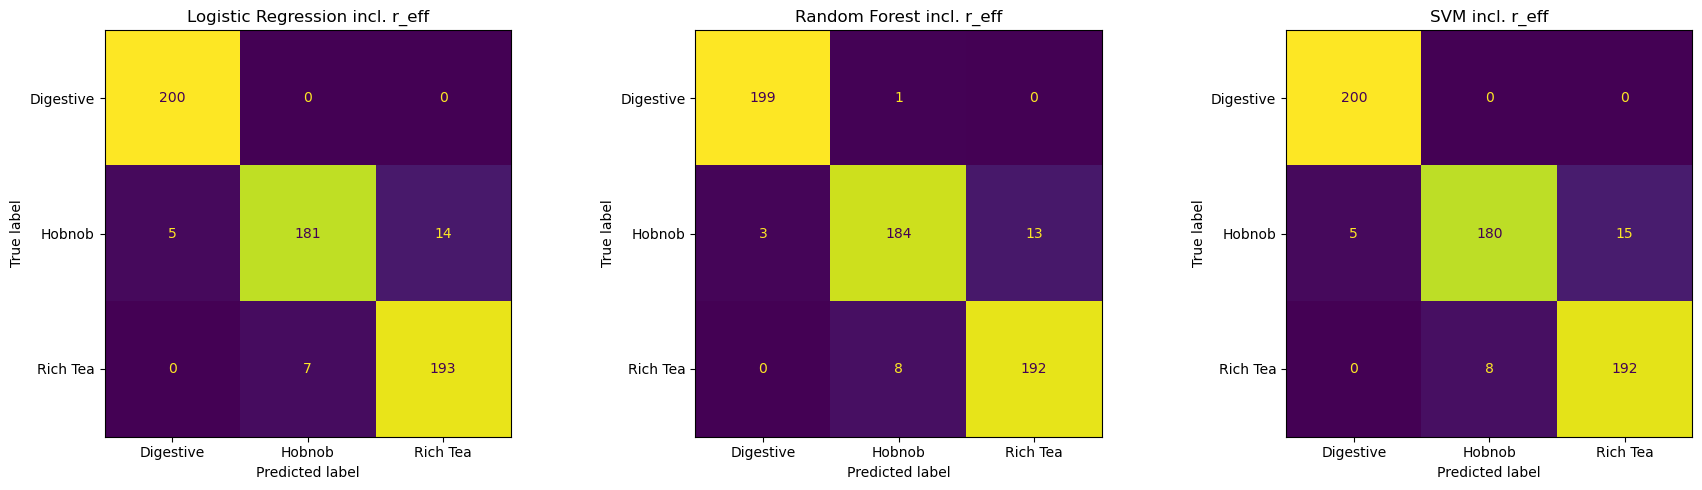


Random forest feature importances:
r_eff    0.772521
L        0.086021
phi      0.057130
t        0.032716
gamma    0.026270
eta      0.025343
dtype: float64


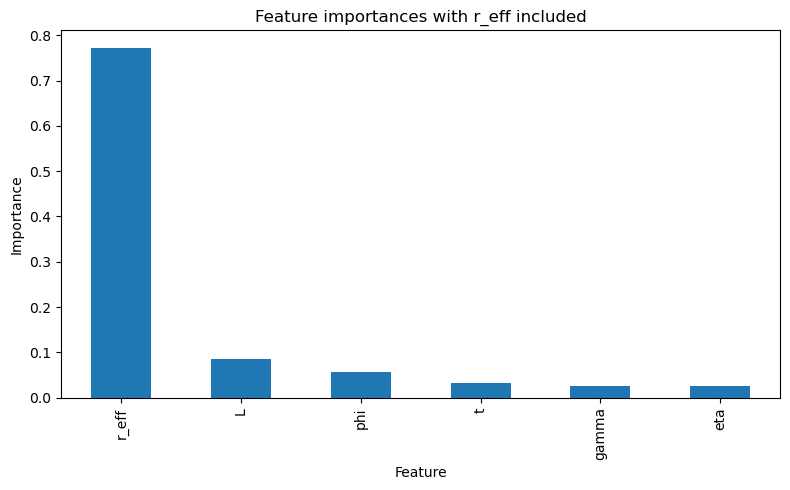


Logistic regression coefficients with r_eff:
              gamma       phi       eta         L         t     r_eff
Digestive -0.155688  0.399117 -0.026910  0.567257 -0.110247  8.211409
Hobnob     0.058122 -0.100349  0.056569 -0.196034  0.054600 -0.047733
Rich Tea   0.097567 -0.298767 -0.029659 -0.371223  0.055648 -8.163675


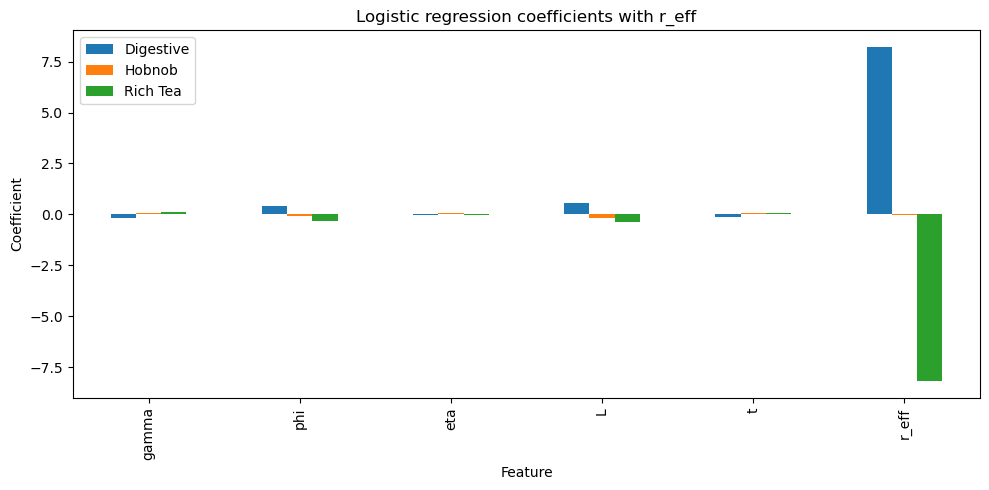


Effect of r_eff on Logistic Regression:
     feature_set  test_accuracy  f1_macro
0  Without r_eff       0.751667  0.745285
1     With r_eff       0.956667  0.956349

MLP incl. r_eff final test accuracy: 0.9550


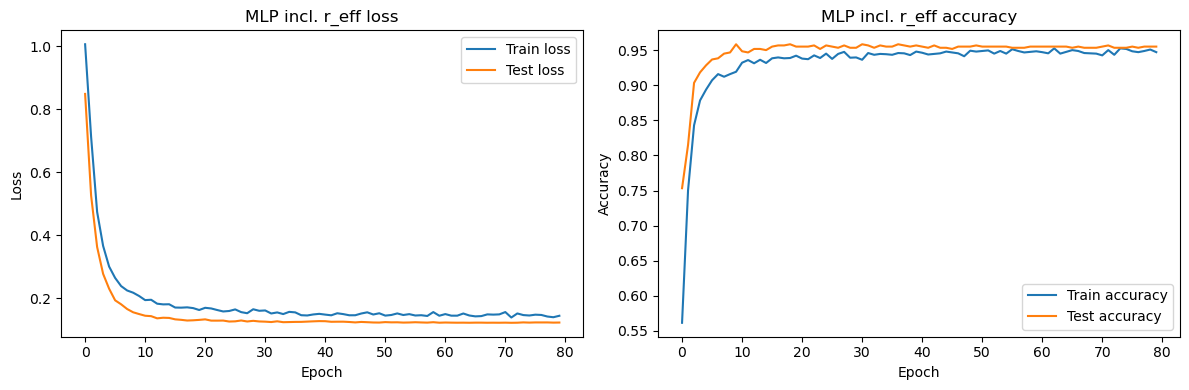


MLP incl. r_eff classification report:
              precision    recall  f1-score   support

   Digestive       0.98      1.00      0.99       200
      Hobnob       0.96      0.91      0.93       200
    Rich Tea       0.93      0.96      0.95       200

    accuracy                           0.95       600
   macro avg       0.96      0.96      0.95       600
weighted avg       0.96      0.95      0.95       600



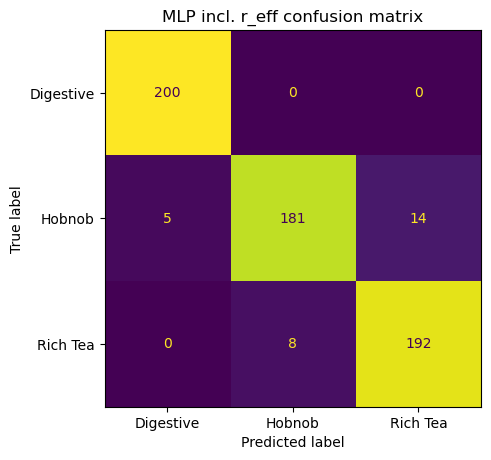

In [6]:
features_phys = ["gamma", "phi", "eta", "L", "t", "r_eff"] #physics-informed classification with r_eff as derived feature
phys_class_data = dunk_phys.dropna(subset=features_phys + ["biscuit"]).copy()

X_phys = phys_class_data[features_phys]
y_phys = label_encoder.transform(phys_class_data["biscuit"])

X_train_phys, X_test_phys, y_train_phys, y_test_phys = train_test_split(X_phys, y_phys, test_size=0.2, random_state=42, stratify=y_phys)

phys_models = {
    "Logistic Regression incl. r_eff": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, random_state=42))]),
    "Random Forest incl. r_eff": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM incl. r_eff": Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", random_state=42))])
}

phys_results = []
fitted_phys_models = {}

for name, model in phys_models.items():
    model.fit(X_train_phys, y_train_phys)
    fitted_phys_models[name] = model
    y_pred = model.predict(X_test_phys)

    acc = accuracy_score(y_test_phys, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test_phys, y_pred, average="macro", zero_division=0)
    phys_results.append({"model": name, "test_accuracy": acc, "precision_macro": prec, "recall_macro": rec, "f1_macro": f1})

phys_results_df = pd.DataFrame(phys_results).sort_values("f1_macro", ascending=False)
print("\nPhysics-informed classification results:")
print(phys_results_df)

for name, model in fitted_phys_models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test_phys)
    print(classification_report(y_test_phys, y_pred, target_names=label_encoder.classes_, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5)) #confusion matrices
for ax, (name, model) in zip(axes, fitted_phys_models.items()):
    y_pred = model.predict(X_test_phys)
    cm = confusion_matrix(y_test_phys, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

rf_phys = fitted_phys_models["Random Forest incl. r_eff"] #random forest feature importances
rf_importance = pd.Series(rf_phys.feature_importances_, index=features_phys).sort_values(ascending=False)
print("\nRandom forest feature importances:")
print(rf_importance)

fig, ax = plt.subplots(figsize=(8, 5))
rf_importance.plot(kind="bar", ax=ax)
ax.set_title("Feature importances with r_eff included")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance")
plt.tight_layout()
plt.show()

log_reg_phys = fitted_phys_models["Logistic Regression incl. r_eff"].named_steps["model"] #logistic regression coefficients
coef_df = pd.DataFrame(log_reg_phys.coef_, columns=features_phys, index=label_encoder.classes_)
print("\nLogistic regression coefficients with r_eff:")
print(coef_df)

fig, ax = plt.subplots(figsize=(10, 5))
coef_df.T.plot(kind="bar", ax=ax)
ax.set_title("Logistic regression coefficients with r_eff")
ax.set_xlabel("Feature")
ax.set_ylabel("Coefficient")
plt.tight_layout()
plt.show()

ablation_rows = [] #effect of adding r_eff
for cols, label in [(["gamma", "phi", "eta", "L", "t"], "Without r_eff"), (["gamma", "phi", "eta", "L", "t", "r_eff"], "With r_eff")]:
    X_ab = phys_class_data[cols]
    X_train_ab, X_test_ab, y_train_ab, y_test_ab = train_test_split(X_ab, y_phys, test_size=0.2, random_state=42, stratify=y_phys)
    model_ab = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, random_state=42))])
    model_ab.fit(X_train_ab, y_train_ab)
    y_pred_ab = model_ab.predict(X_test_ab)
    acc_ab = accuracy_score(y_test_ab, y_pred_ab)
    _, _, f1_ab, _ = precision_recall_fscore_support(y_test_ab, y_pred_ab, average="macro", zero_division=0)
    ablation_rows.append({"feature_set": label, "test_accuracy": acc_ab, "f1_macro": f1_ab})

print("\nEffect of r_eff on Logistic Regression:")
print(pd.DataFrame(ablation_rows))

scaler_mlp_phys = StandardScaler() #MLP incl. r_eff with dropout and learning rate scheduler
X_train_phys_scaled = scaler_mlp_phys.fit_transform(X_train_phys)
X_test_phys_scaled = scaler_mlp_phys.transform(X_test_phys)

X_train_phys_tensor = torch.tensor(X_train_phys_scaled, dtype=torch.float32)
X_test_phys_tensor = torch.tensor(X_test_phys_scaled, dtype=torch.float32)
y_train_phys_tensor = torch.tensor(y_train_phys, dtype=torch.long)
y_test_phys_tensor = torch.tensor(y_test_phys, dtype=torch.long)

train_loader_phys = DataLoader(TensorDataset(X_train_phys_tensor, y_train_phys_tensor), batch_size=64, shuffle=True)
test_loader_phys = DataLoader(TensorDataset(X_test_phys_tensor, y_test_phys_tensor), batch_size=64, shuffle=False)

mlp_phys = BiscuitMLP(input_dim=X_train_phys_tensor.shape[1], n_classes=len(label_encoder.classes_))
loss_fn_phys = nn.CrossEntropyLoss()
optimizer_phys = torch.optim.Adam(mlp_phys.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_phys = torch.optim.lr_scheduler.StepLR(optimizer_phys, step_size=20, gamma=0.5) #halve LR every 20 epochs

train_losses_phys, test_losses_phys, train_accs_phys, test_accs_phys = [], [], [], []

for epoch in range(80):
    mlp_phys.train()
    run_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_loader_phys:
        optimizer_phys.zero_grad()
        out = mlp_phys(X_batch)
        loss = loss_fn_phys(out, y_batch)
        loss.backward()
        optimizer_phys.step()
        run_loss += loss.item() * X_batch.size(0)
        correct += (out.argmax(1) == y_batch).sum().item()
        total += y_batch.size(0)
    scheduler_phys.step()
    train_losses_phys.append(run_loss / total)
    train_accs_phys.append(correct / total)

    mlp_phys.eval()
    run_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader_phys:
            out = mlp_phys(X_batch)
            run_loss += loss_fn_phys(out, y_batch).item() * X_batch.size(0)
            correct += (out.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)
    test_losses_phys.append(run_loss / total)
    test_accs_phys.append(correct / total)

print(f"\nMLP incl. r_eff final test accuracy: {test_accs_phys[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4)) #training curves
axes[0].plot(train_losses_phys, label="Train loss")
axes[0].plot(test_losses_phys, label="Test loss")
axes[0].set_title("MLP incl. r_eff loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(train_accs_phys, label="Train accuracy")
axes[1].plot(test_accs_phys, label="Test accuracy")
axes[1].set_title("MLP incl. r_eff accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

mlp_phys.eval()
all_preds_phys, all_true_phys = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader_phys:
        preds = mlp_phys(X_batch).argmax(1)
        all_preds_phys.extend(preds.numpy())
        all_true_phys.extend(y_batch.numpy())

print("\nMLP incl. r_eff classification report:")
print(classification_report(all_true_phys, all_preds_phys, target_names=label_encoder.classes_, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 5))
cm = confusion_matrix(all_true_phys, all_preds_phys)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_).plot(ax=ax, colorbar=False)
ax.set_title("MLP incl. r_eff confusion matrix")
plt.tight_layout()
plt.show()

Regression dataset shape: (500, 11)
Feature columns: ['gamma', 'phi', 'eta', 't', 'r']
Target column: L

Training set shape: (400, 5)
Test set shape: (100, 5)

Regression comparison:
                           model       MAE      RMSE        R2  cv_RMSE_mean  \
0              Washburn equation  0.000049  0.000068  0.999407      0.000064   
2  Polynomial Regression (deg=2)  0.000232  0.000314  0.987507      0.000371   
4                      SVR (RBF)  0.000257  0.000379  0.981804      0.000600   
3        Random Forest Regressor  0.000391  0.000495  0.968961      0.000620   
1              Linear Regression  0.000708  0.000897  0.898125      0.000959   

   cv_RMSE_std  
0     0.000008  
2     0.000060  
4     0.000211  
3     0.000082  
1     0.000049  


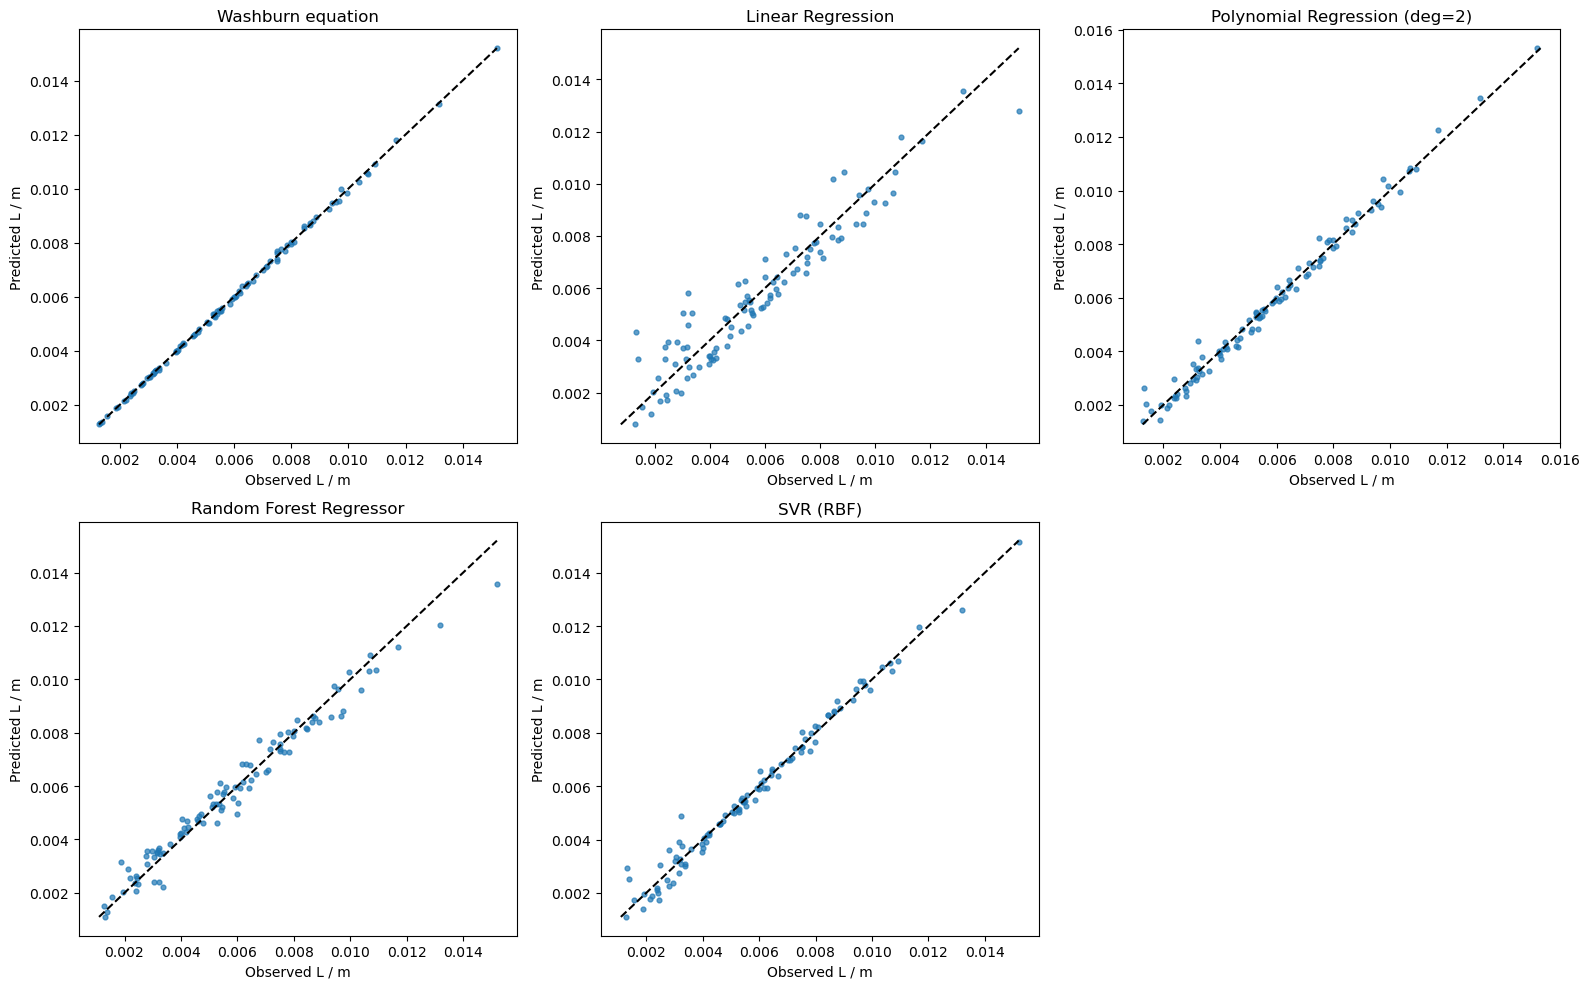

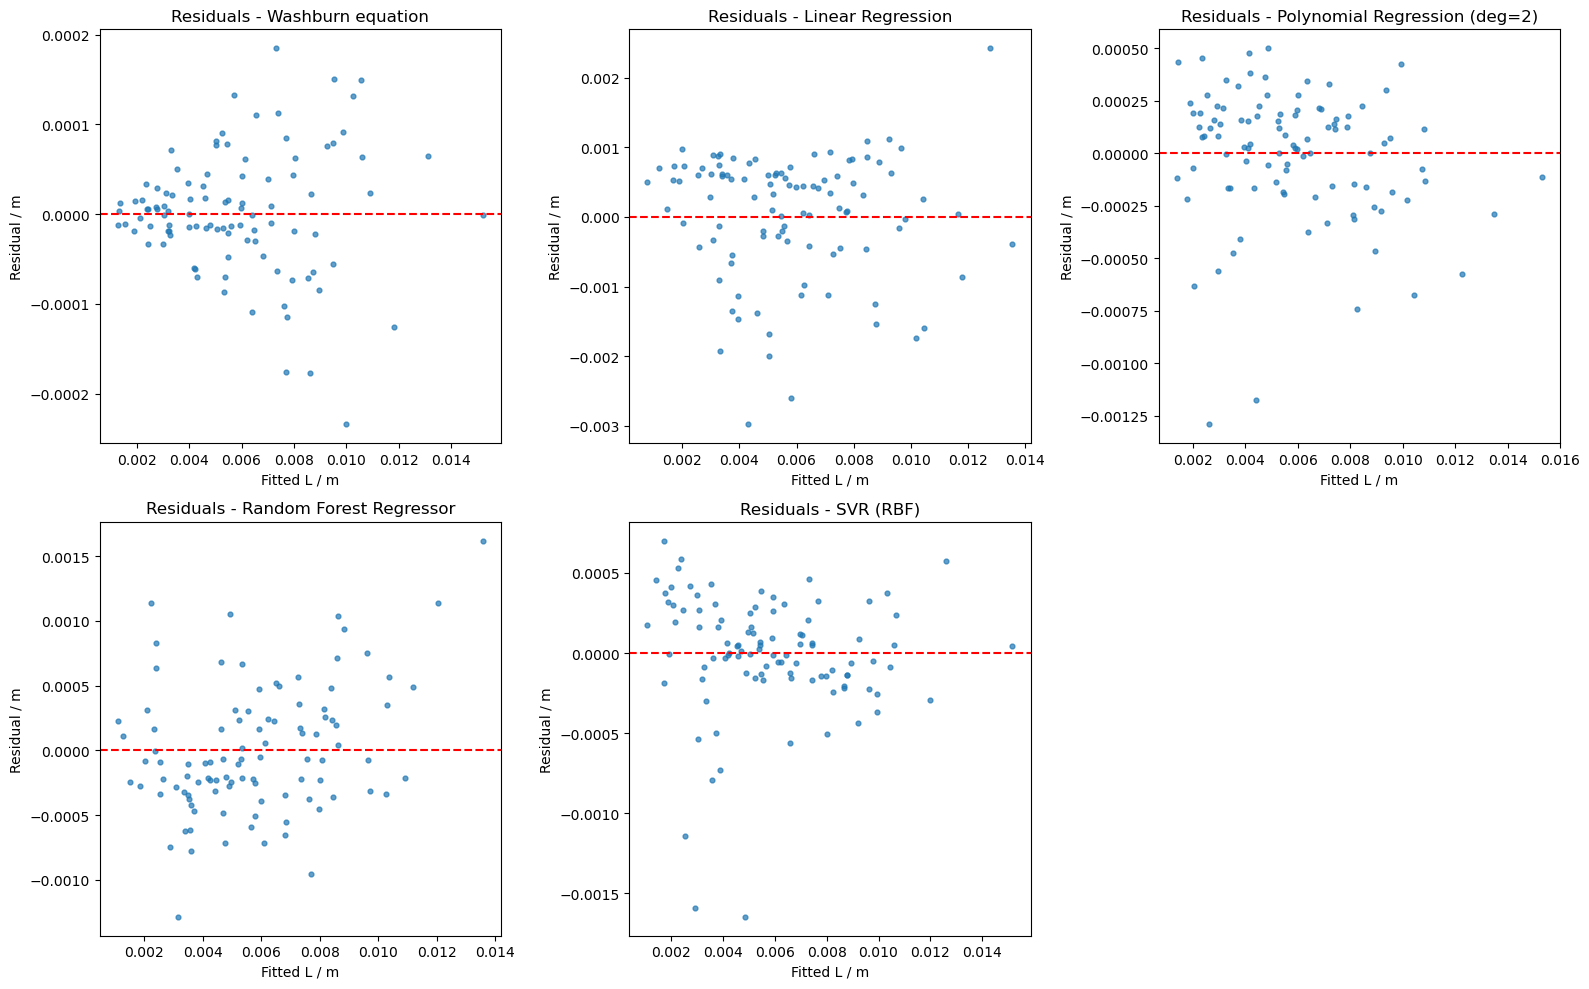


RF regressor feature importances:
phi      0.693708
r        0.197968
t        0.079409
gamma    0.021163
eta      0.007752
dtype: float64


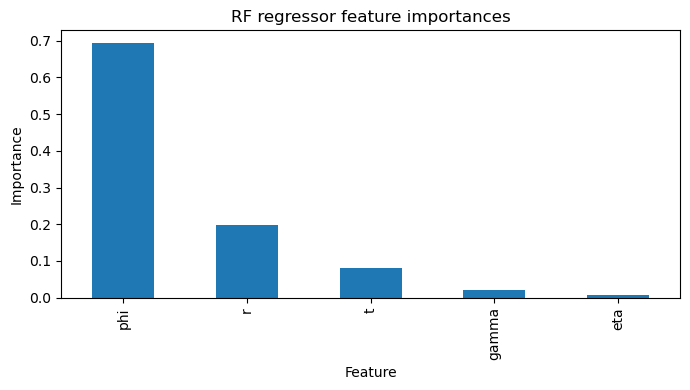


Effect of measured pore radius:
    features       MAE      RMSE        R2
0  Without r  0.001240  0.001507  0.712567
1     With r  0.000708  0.000897  0.898125


In [7]:
regression_data = micro_phys.dropna(subset=["gamma", "phi", "eta", "t", "r", "L"]).copy() #regression using microscopy data 

feature_cols_reg = ["gamma", "phi", "eta", "t", "r"]
target_col = "L"

X_reg = regression_data[feature_cols_reg]
y_reg = regression_data[target_col]

print("Regression dataset shape:", regression_data.shape)
print("Feature columns:", feature_cols_reg)
print("Target column:", target_col)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print("\nTraining set shape:", X_train_reg.shape)
print("Test set shape:", X_test_reg.shape)

y_pred_washburn = washburn_length(r=X_test_reg["r"].values, gamma=X_test_reg["gamma"].values, t=X_test_reg["t"].values, phi=X_test_reg["phi"].values, eta=X_test_reg["eta"].values)

reg_models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Polynomial Regression (deg=2)": Pipeline([("poly", PolynomialFeatures(degree=2, include_bias=False)), ("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=300, random_state=42),
    "SVR (RBF)": Pipeline([("scaler", StandardScaler()), ("model", SVR(kernel="rbf", C=10, epsilon=1e-4))])
}

reg_results = []
fitted_reg_models = {}

cv_splitter_reg = KFold(n_splits=5, shuffle=True, random_state=42)

washburn_metrics = evaluate_regression(y_test_reg, y_pred_washburn) #evaluate Washburn on same test set

washburn_cv_scores = [] #evaluate Washburn on same CV folds for fair comparison
for train_idx, val_idx in cv_splitter_reg.split(X_reg):
    X_val_fold = X_reg.iloc[val_idx]
    y_val_fold = y_reg.iloc[val_idx]
    y_pred_fold = washburn_length(r=X_val_fold["r"].values, gamma=X_val_fold["gamma"].values, t=X_val_fold["t"].values, phi=X_val_fold["phi"].values, eta=X_val_fold["eta"].values)
    washburn_cv_scores.append(rmse(y_val_fold.values, y_pred_fold))

reg_results.append({"model": "Washburn equation", "MAE": washburn_metrics["MAE"], "RMSE": washburn_metrics["RMSE"], "R2": washburn_metrics["R2"], "cv_RMSE_mean": np.mean(washburn_cv_scores), "cv_RMSE_std": np.std(washburn_cv_scores)})

for name, model in reg_models.items():
    model.fit(X_train_reg, y_train_reg)
    fitted_reg_models[name] = model
    y_pred = model.predict(X_test_reg)
    metrics = evaluate_regression(y_test_reg, y_pred)
    cv_scores = cross_val_score(model, X_reg, y_reg, cv=cv_splitter_reg, scoring="neg_root_mean_squared_error")
    reg_results.append({"model": name, "MAE": metrics["MAE"], "RMSE": metrics["RMSE"], "R2": metrics["R2"], "cv_RMSE_mean": -cv_scores.mean(), "cv_RMSE_std": cv_scores.std()})

reg_results_df = pd.DataFrame(reg_results).sort_values("RMSE")
print("\nRegression comparison:")
print(reg_results_df)

prediction_dict = {"Washburn equation": y_pred_washburn} #store predictions for plotting
for name, model in fitted_reg_models.items():
    prediction_dict[name] = model.predict(X_test_reg)

fig, axes = plt.subplots(2, 3, figsize=(16, 10)) #observed vs predicted plots
axes = axes.flatten()
for ax, (name, y_pred) in zip(axes, prediction_dict.items()):
    low = min(y_test_reg.min(), np.nanmin(y_pred))
    high = max(y_test_reg.max(), np.nanmax(y_pred))
    ax.scatter(y_test_reg, y_pred, alpha=0.7, s=12)
    ax.plot([low, high], [low, high], "k--")
    ax.set_title(name)
    ax.set_xlabel("Observed L / m")
    ax.set_ylabel("Predicted L / m")
for j in range(len(prediction_dict), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 10)) #residuals vs fitted plots
axes = axes.flatten()
for ax, (name, y_pred) in zip(axes, prediction_dict.items()):
    residuals = np.asarray(y_test_reg) - np.asarray(y_pred)
    ax.scatter(y_pred, residuals, alpha=0.7, s=12)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(f"Residuals - {name}")
    ax.set_xlabel("Fitted L / m")
    ax.set_ylabel("Residual / m")
for j in range(len(prediction_dict), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

rf_reg = fitted_reg_models["Random Forest Regressor"] #feature importances
rf_reg_importance = pd.Series(rf_reg.feature_importances_, index=feature_cols_reg).sort_values(ascending=False)
print("\nRF regressor feature importances:")
print(rf_reg_importance)

fig, ax = plt.subplots(figsize=(7, 4))
rf_reg_importance.plot(kind="bar", ax=ax)
ax.set_title("RF regressor feature importances")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance")
plt.tight_layout()
plt.show()

ablation_reg = [] #ablation: with vs without measured r
for cols, label in [(["gamma", "phi", "eta", "t"], "Without r"), (["gamma", "phi", "eta", "t", "r"], "With r")]:
    X_ab = regression_data[cols]
    X_train_ab, X_test_ab, y_train_ab, y_test_ab = train_test_split(X_ab, y_reg, test_size=0.2, random_state=42)
    model_ab = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
    model_ab.fit(X_train_ab, y_train_ab)
    m = evaluate_regression(y_test_ab, model_ab.predict(X_test_ab))
    ablation_reg.append({"features": label, "MAE": m["MAE"], "RMSE": m["RMSE"], "R2": m["R2"]})

print("\nEffect of measured pore radius:")
print(pd.DataFrame(ablation_reg))

Labelled biscuit r_eff summary:
           count          mean        median           std           min  \
biscuit                                                                    
Digestive   1000  8.021261e-07  8.049362e-07  5.964216e-08  6.766981e-07   
Hobnob      1000  5.003074e-07  5.008655e-07  8.079370e-08  2.337422e-07   
Rich Tea    1000  3.020585e-07  3.038294e-07  5.068362e-08  1.328849e-07   

                    max  
biscuit                  
Digestive  9.361785e-07  
Hobnob     7.763628e-07  
Rich Tea   4.617529e-07  

Blind sample identification summary:
  sample    mean_r_eff      fitted_r best_by_mean_r best_by_median_r best_by_kde best_by_curve_wrmse  consensus votes  wrmse_digestive  wrmse_hobnob  wrmse_rich_tea
0   tr-1  5.190558e-07  5.186196e-07         Hobnob           Hobnob      Hobnob              Hobnob     Hobnob   4/4         0.004579      0.000385        0.004451
1   tr-2  2.794291e-07  2.802635e-07       Rich Tea         Rich Tea    Rich Tea         

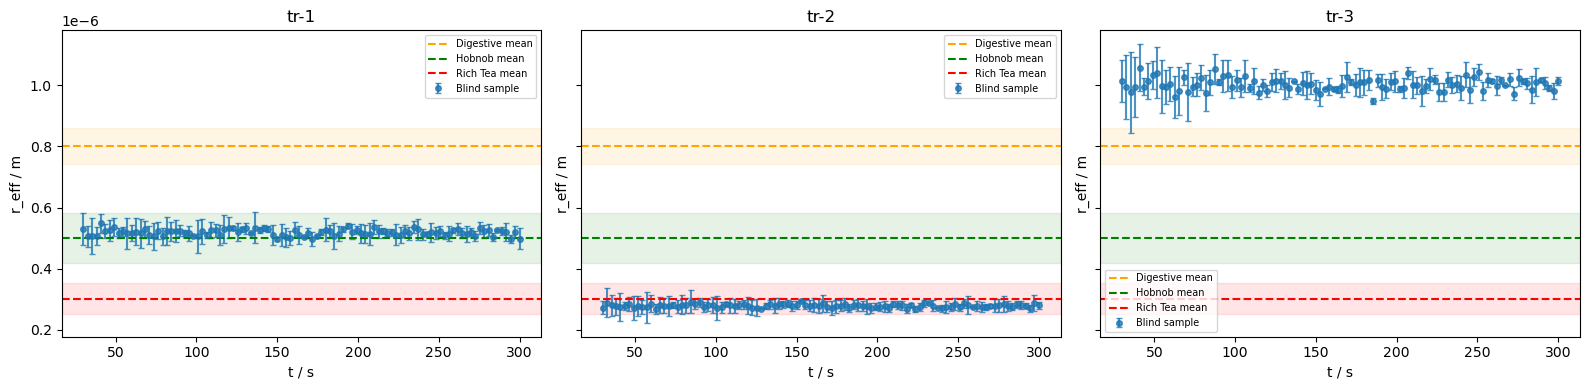


Final blind sample identifications:
tr-1 = Hobnob (4/4 criteria agree)
tr-2 = Rich Tea (4/4 criteria agree)
tr-3 = Digestive (4/4 criteria agree)


In [8]:
labelled_radius_stats = (dunk_phys.groupby("biscuit")["r_eff"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("mean", ascending=False))
print("Labelled biscuit r_eff summary:")
print(labelled_radius_stats)

radius_kdes = {} #build KDEs on labelled class radius distributions
for biscuit in biscuit_order:
    values = dunk_phys.loc[dunk_phys["biscuit"] == biscuit, "r_eff"].dropna().values
    radius_kdes[biscuit] = gaussian_kde(values)

def kde_loglikelihood(sample_values, kde):
    vals = np.asarray(sample_values)
    dens = kde(vals)
    dens = np.clip(dens, 1e-300, None)
    return np.sum(np.log(dens))

def weighted_rmse(y_true, y_pred, y_err): #weighted RMSE using dL uncertainties
    w = 1.0 / np.square(y_err)
    return np.sqrt(np.sum(w * (y_true - y_pred)**2) / np.sum(w))

summary_rows = []

for sample_name, df in blind_phys.items():
    sample_mean_r = df["r_eff"].mean()
    sample_median_r = df["r_eff"].median()

    mean_diff, median_diff, kde_loglik, curve_wrmse = {}, {}, {}, {}

    for biscuit, row in labelled_radius_stats.iterrows():
        mean_diff[biscuit] = abs(sample_mean_r - row["mean"])
        median_diff[biscuit] = abs(sample_median_r - row["median"])
        kde_loglik[biscuit] = kde_loglikelihood(df["r_eff"].dropna().values, radius_kdes[biscuit])

        pred_L = washburn_curve(df["t"].values, row["mean"]) #predict L using each class mean r
        curve_wrmse[biscuit] = weighted_rmse(df["L"].values, pred_L, df["dL"].values)

    best_by_mean = min(mean_diff, key=mean_diff.get)
    best_by_median = min(median_diff, key=median_diff.get)
    best_by_kde = max(kde_loglik, key=kde_loglik.get)
    best_by_curve = min(curve_wrmse, key=curve_wrmse.get)

    votes = [best_by_mean, best_by_median, best_by_kde, best_by_curve]
    consensus = pd.Series(votes).value_counts().idxmax()
    n_votes = pd.Series(votes).value_counts().max()

    summary_rows.append({"sample": sample_name, "mean_r_eff": sample_mean_r, "fitted_r": blind_fit_results[sample_name]["r_fit"], "best_by_mean_r": best_by_mean, "best_by_median_r": best_by_median, "best_by_kde": best_by_kde, "best_by_curve_wrmse": best_by_curve, "consensus": consensus, "votes": f"{n_votes}/4", "wrmse_digestive": curve_wrmse["Digestive"], "wrmse_hobnob": curve_wrmse["Hobnob"], "wrmse_rich_tea": curve_wrmse["Rich Tea"],})

blind_summary = pd.DataFrame(summary_rows)
print("\nBlind sample identification summary:")
print(blind_summary.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True) #r_eff vs t plots with class bands

for ax, (sample_name, df) in zip(axes, blind_phys.items()):
    ax.errorbar(df["t"], df["r_eff"], yerr=df["dr_eff"], fmt="o", capsize=2, ms=4, alpha=0.8, label="Blind sample")
    colours = {"Digestive": "orange", "Hobnob": "green", "Rich Tea": "red"}
    for biscuit, colour in colours.items():
        mu = labelled_radius_stats.loc[biscuit, "mean"]
        sigma = labelled_radius_stats.loc[biscuit, "std"]
        ax.axhline(mu, color=colour, linestyle="--", label=f"{biscuit} mean")
        ax.axhspan(mu - sigma, mu + sigma, alpha=0.1, color=colour)
    ax.set_title(sample_name)
    ax.set_xlabel("t / s")
    ax.set_ylabel("r_eff / m")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

print("\nFinal blind sample identifications:")
for _, row in blind_summary.iterrows():
    print(f"{row['sample']} = {row['consensus']} ({row['votes']} criteria agree)")
